In [2]:
from pathlib import Path

# Lokalna ścieżka do pobranego datasetu
dataset_root = Path("whole")
print("Dataset root:", dataset_root.resolve())
print("Splits:", [p.name for p in dataset_root.iterdir() if p.is_dir()])

Dataset root: E:\Studia\DL-deepfake-detection\whole
Splits: ['test', 'train', 'val']


In [3]:
import os
from collections import Counter
import matplotlib.pyplot as plt
from PIL import Image

IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

# Mapowanie podfolderów -> {split: {"real": Path, "fake": Path}}
SPLIT_MAP = {
    "train": {"real": "real",       "fake": "fake"},
    "val":   {"real": "valid_real", "fake": "valid_fake"},
    "test":  {"real": "test_real",  "fake": "test_fake"},
}

splits = {}
for split, mapping in SPLIT_MAP.items():
    splits[split] = {cls: dataset_root / split / sub for cls, sub in mapping.items()}

for split, classes in splits.items():
    print(f"{split}: {[(c, p.exists()) for c, p in classes.items()]}")

train: [('real', True), ('fake', True)]
val: [('real', True), ('fake', True)]
test: [('real', True), ('fake', True)]


Liczba obrazów:
  train -> real:   3143, fake:   3204, total: 6347
  val   -> real:    331, fake:    312, total: 643
  test  -> real:    416, fake:    416, total: 832


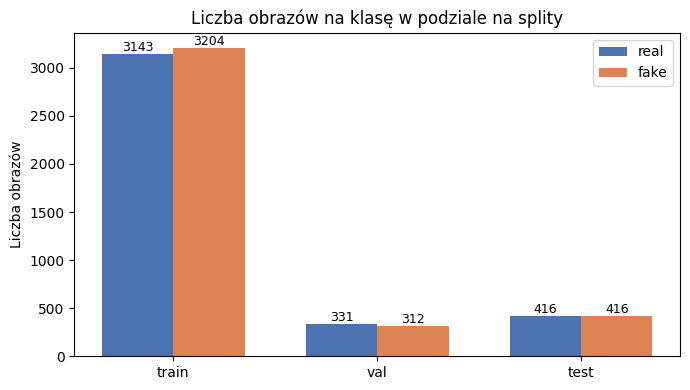

In [ ]:
# Zliczenie plików w każdym splicie i klasie
def list_images(folder: Path):
    return [f for f in folder.iterdir() if f.suffix.lower() in IMG_EXT]

counts = {split: {cls: len(list_images(p)) for cls, p in classes.items()}
          for split, classes in splits.items()}

print("Liczba obrazów:")
for split, by_cls in counts.items():
    total = sum(by_cls.values())
    print(f"  {split:5s} -> real: {by_cls['real']:>6}, fake: {by_cls['fake']:>6}, total: {total}")

# Wykres słupkowy 
import numpy as np
split_names = list(counts.keys())
real_vals = [counts[s]["real"] for s in split_names]
fake_vals = [counts[s]["fake"] for s in split_names]
x = np.arange(len(split_names))
w = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, real_vals, w, label="real", color="#4C72B0")
ax.bar(x + w/2, fake_vals, w, label="fake", color="#DD8452")
ax.set_xticks(x); ax.set_xticklabels(split_names)
ax.set_ylabel("Liczba obrazów")
ax.set_title("Liczba obrazów na klasę w podziale na splity")
for i, (r, f) in enumerate(zip(real_vals, fake_vals)):
    ax.text(i - w/2, r, str(r), ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, f, str(f), ha="center", va="bottom", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

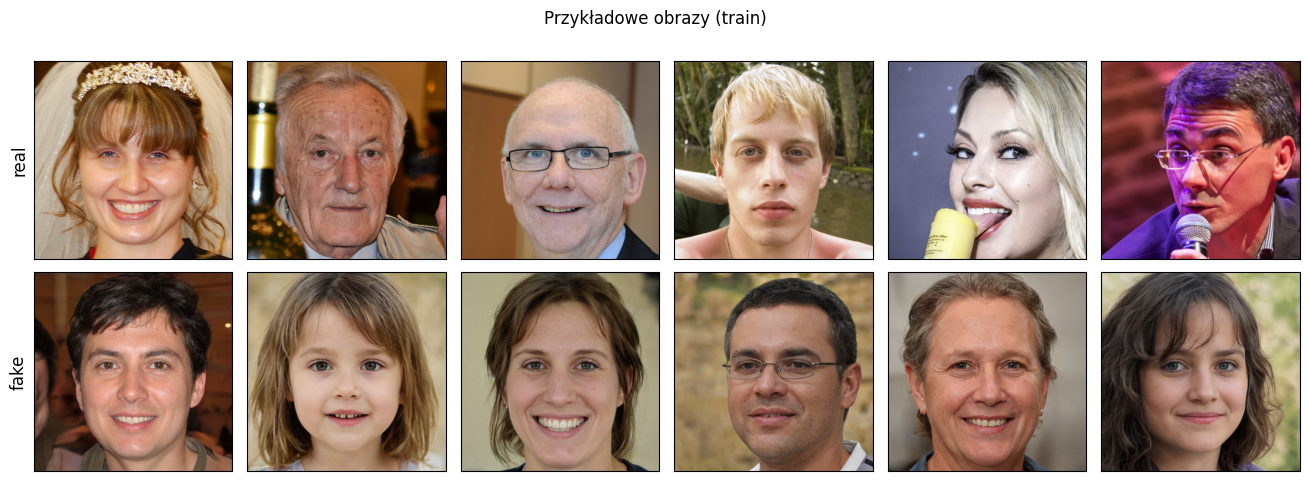

In [5]:
# Przykładowe obrazy: po kilka real / fake z train
import random

n_per_class = 6
sample_split = "train"

fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 2.2, 5))
for row, cls in enumerate(["real", "fake"]):
    files = list_images(splits[sample_split][cls])
    chosen = random.sample(files, min(n_per_class, len(files)))
    for col in range(n_per_class):
        ax = axes[row][col]
        if col < len(chosen):
            with Image.open(chosen[col]) as img:
                ax.imshow(img.convert("RGB"))
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=12)

plt.suptitle(f"Przykładowe obrazy ({sample_split})")
plt.tight_layout()
plt.show()

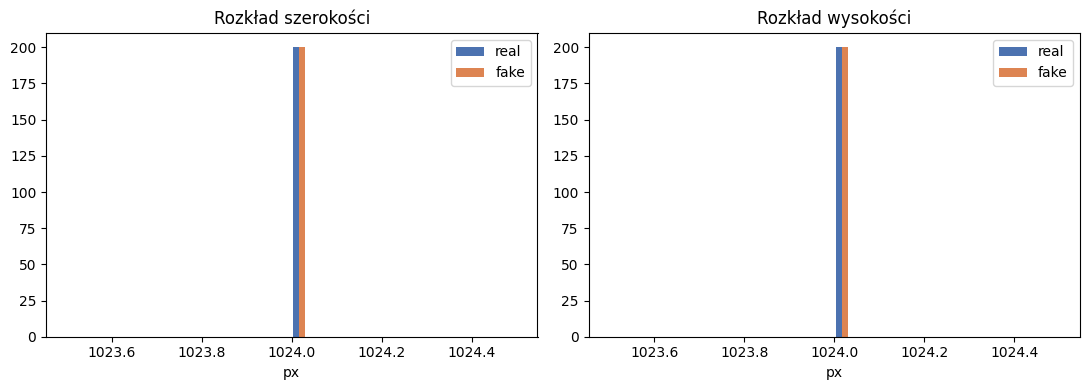

Najczęstsze wymiary (W x H) w train:
  1024x1024: 400


In [6]:
# Rozkład wymiarów obrazów (próba do 200 plików na klasę z train)
sample_size = 200
sizes = []  # (cls, w, h)
for cls, p in splits["train"].items():
    files = list_images(p)
    for f in random.sample(files, min(sample_size, len(files))):
        try:
            with Image.open(f) as img:
                sizes.append((cls, img.width, img.height))
        except Exception:
            pass

real_w = [w for c, w, _ in sizes if c == "real"]
fake_w = [w for c, w, _ in sizes if c == "fake"]
real_h = [h for c, _, h in sizes if c == "real"]
fake_h = [h for c, _, h in sizes if c == "fake"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist([real_w, fake_w], bins=30, label=["real", "fake"],
             color=["#4C72B0", "#DD8452"])
axes[0].set_title("Rozkład szerokości"); axes[0].set_xlabel("px"); axes[0].legend()
axes[1].hist([real_h, fake_h], bins=30, label=["real", "fake"],
             color=["#4C72B0", "#DD8452"])
axes[1].set_title("Rozkład wysokości"); axes[1].set_xlabel("px"); axes[1].legend()
plt.tight_layout()
plt.show()

print("Najczęstsze wymiary (W x H) w train:")
for dim, c in Counter([(w, h) for _, w, h in sizes]).most_common(5):
    print(f"  {dim[0]}x{dim[1]}: {c}")

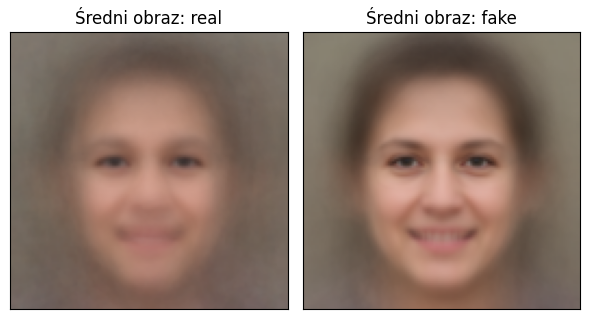

In [7]:
# Średni obraz per klasa (z train) - pomocne aby zobaczyć "uśrednione" cechy
import numpy as np

target_size = (128, 128)
mean_imgs = {}
sample_for_mean = 300

for cls, p in splits["train"].items():
    files = list_images(p)
    chosen = random.sample(files, min(sample_for_mean, len(files)))
    acc = np.zeros((target_size[1], target_size[0], 3), dtype=np.float64)
    n = 0
    for f in chosen:
        try:
            with Image.open(f) as img:
                arr = np.asarray(img.convert("RGB").resize(target_size), dtype=np.float64)
                acc += arr
                n += 1
        except Exception:
            pass
    mean_imgs[cls] = (acc / max(n, 1)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3.5))
for ax, (cls, img) in zip(axes, mean_imgs.items()):
    ax.imshow(img)
    ax.set_title(f"Średni obraz: {cls}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()